# 添加条形图示例

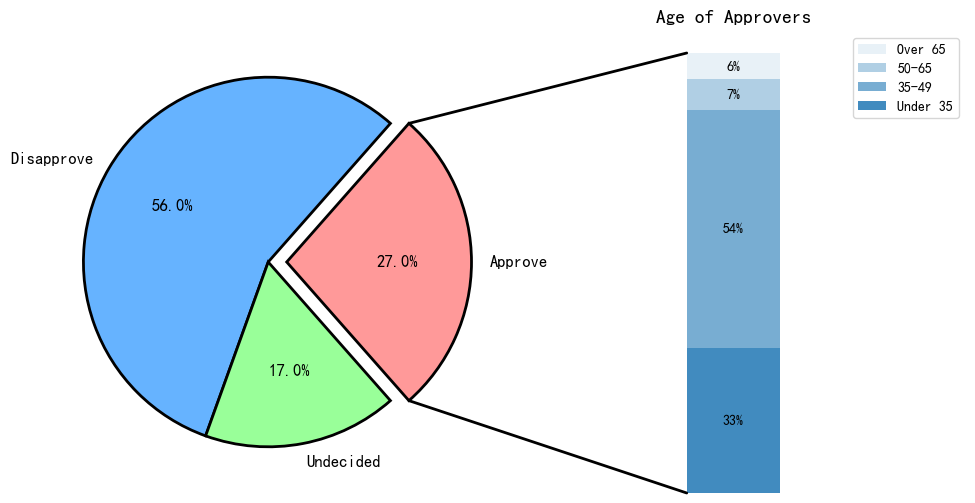

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import ConnectionPatch

# 创建画布和子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(wspace=0)  # 调整子图间距

# 饼图参数
overall_ratios = [0.27, 0.56, 0.17]  # 各扇区的占比
labels = ['Approve', 'Disapprove', 'Undecided']  # 扇区标签
explode = [0.1, 0, 0]  # 突出显示第一个扇区
angle = -180 * overall_ratios[0]  # 旋转角度，使第一个扇区从 x 轴开始

# 绘制饼图
wedges, texts, autotexts = ax1.pie(
    overall_ratios,
    explode=explode,
    labels=labels,
    autopct='%1.1f%%',
    startangle=angle,
    colors=['#ff9999', '#66b3ff', '#99ff99'],  # 自定义颜色
    wedgeprops={'edgecolor': 'black', 'linewidth': 2},  # 扇区边框样式
    textprops={'fontsize': 12, 'color': 'black'},  # 文本样式
)

# 条形图参数
age_ratios = [0.33, 0.54, 0.07, 0.06]  # 各年龄段的占比
age_labels = ['Under 35', '35-49', '50-65', 'Over 65']  # 年龄段标签
bottom = 1  # 条形图的起始位置
width = 0.2  # 条形图的宽度

# 绘制条形图
for j, (height, label) in enumerate(reversed([*zip(age_ratios, age_labels)])):
    bottom -= height  # 计算每个条形图的底部位置
    bc = ax2.bar(
        0, height, width, bottom=bottom, color='C0', label=label,
        alpha=0.1 + 0.25 * j  # 设置透明度
    )
    ax2.bar_label(bc, labels=[f"{height:.0%}"], label_type='center')  # 添加百分比标签

# 设置条形图标题和图例
ax2.set_title('Age of Approvers', fontsize=14)
ax2.legend(loc='upper right')
ax2.axis('off')  # 隐藏坐标轴
ax2.set_xlim(-2.5 * width, 2.5 * width)  # 设置 x 轴范围

# 使用 ConnectionPatch 绘制连接线
theta1, theta2 = wedges[0].theta1, wedges[0].theta2  # 获取第一个扇区的起始和结束角度
center, r = wedges[0].center, wedges[0].r  # 获取饼图的中心和半径
bar_height = sum(age_ratios)  # 条形图的总高度

# 绘制顶部连接线
x = r * np.cos(np.pi / 180 * theta2) + center[0]  # 计算连接点的 x 坐标
y = r * np.sin(np.pi / 180 * theta2) + center[1]  # 计算连接点的 y 坐标
con = ConnectionPatch(
    xyA=(-width / 2, bar_height), coordsA=ax2.transData,  # 条形图的连接点
    xyB=(x, y), coordsB=ax1.transData,  # 饼图的连接点
    color='black', linewidth=2  # 连接线样式
)
ax2.add_artist(con)

# 绘制底部连接线
x = r * np.cos(np.pi / 180 * theta1) + center[0]  # 计算连接点的 x 坐标
y = r * np.sin(np.pi / 180 * theta1) + center[1]  # 计算连接点的 y 坐标
con = ConnectionPatch(
    xyA=(-width / 2, 0), coordsA=ax2.transData,  # 条形图的连接点
    xyB=(x, y), coordsB=ax1.transData,  # 饼图的连接点
    color='black', linewidth=2  # 连接线样式
)
ax2.add_artist(con)
plt.savefig("添加条形图饼图.png", dpi=300)
# 显示图形
plt.show()